In [2]:
import mesa_data as md
import numpy as np

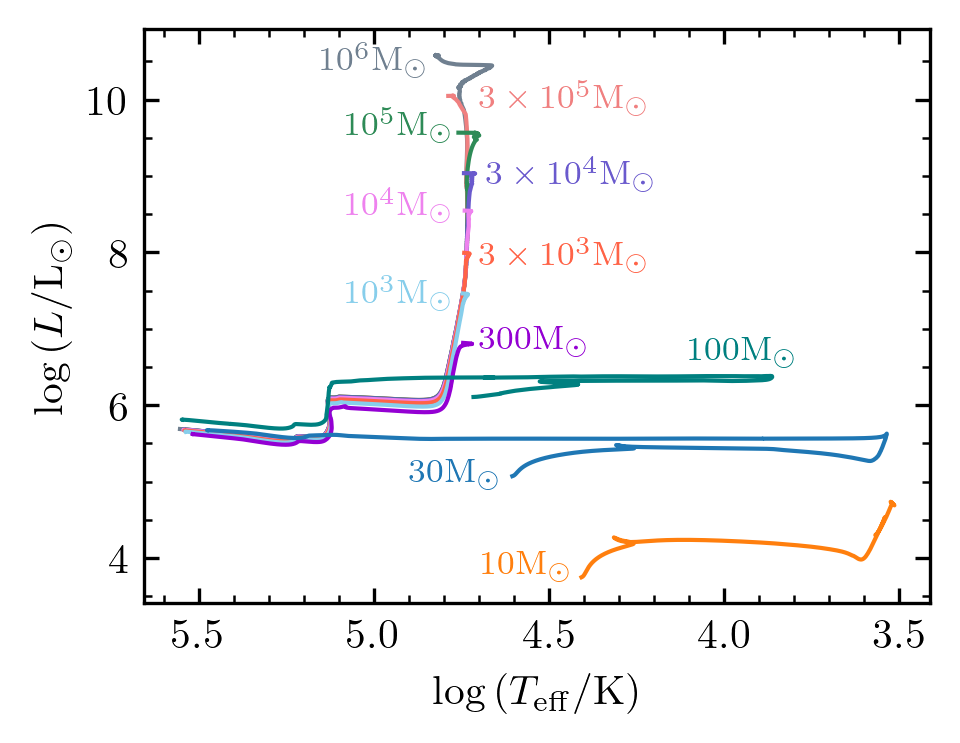

In [3]:
import matplotlib.pyplot as plt

plt.style.use("mesa.mplstyle")

histories = [md.mesa_data("single/1e1/LOGS/history.data"),
            md.mesa_data("single/3e1/LOGS/history.data"),
            md.mesa_data("single/1e2/LOGS/history.data"),
            md.mesa_data("single/3e2/LOGS/history.data"),
            md.mesa_data("single/1e3/LOGS/history.data"),
            md.mesa_data("single/3e3/LOGS/history.data"),
            md.mesa_data("single/1e4/LOGS/history.data"),
            md.mesa_data("single/3e4/LOGS/history.data"),
            md.mesa_data("single/1e5/LOGS/history.data"),
            md.mesa_data("single/3e5/LOGS/history.data"),
            md.mesa_data("single/1e6/LOGS/history.data")]

colors = ["tab:orange", "tab:blue", "teal", "darkviolet", "skyblue", "tomato", "violet", "slateblue",
          "seagreen", "lightcoral","slategray"][::-1]

for k, premerger in enumerate(histories[::-1]):
    for i in range(len(premerger.get("log_Teff"))):
        if premerger.get("center_h1")[i]<0.71:
            i_th = i
            break
    plt.plot(premerger.get("log_Teff")[i_th:-2], premerger.get("log_L")[i_th:-2],lw=1,ls="-", color=colors[k])

plt.text(4.69,3.8,"$10\\mathrm{M}_\odot$",color="tab:orange",fontsize=8)
plt.text(4.9,5,"$30\\mathrm{M}_\odot$",color="tab:blue",fontsize=8)
plt.text(4.1,6.6,"$100\\mathrm{M}_\odot$",color="teal",fontsize=8)
plt.text(4.7,6.75,"$300\\mathrm{M}_\odot$",color="darkviolet",fontsize=8)
plt.text(5.08,7.35,"$10^3 \\mathrm{M}_\odot$",color="skyblue",fontsize=8)
plt.text(4.7,7.85,"$3\\times 10^3 \\mathrm{M}_\odot$",color="tomato",fontsize=8)
plt.text(5.08,8.5,"$10^4 \\mathrm{M}_\odot$",color="violet",fontsize=8)
plt.text(4.68,8.9,"$3\\times 10^4 \\mathrm{M}_\odot$",color="slateblue",fontsize=8)
plt.text(5.08,9.55,"$10^5 \\mathrm{M}_\odot$",color="seagreen",fontsize=8)
plt.text(4.7,9.9,"$3\\times 10^5 \\mathrm{M}_\odot$",color="lightcoral",fontsize=8)
plt.text(5.15,10.4,"$10^6 \\mathrm{M}_\odot$",color="slategray",fontsize=8)

plt.gca().set_xlabel("$\\log\\left(T_\mathrm{eff}/\mathrm{K}\\right)$")
plt.gca().set_ylabel("$\\log\\left(L/\\mathrm{L}_\\odot\\right)$")
plt.gca().invert_xaxis()
#plt.gca().set_xlim([5,3.5])

plt.savefig("HR_superad.pdf")

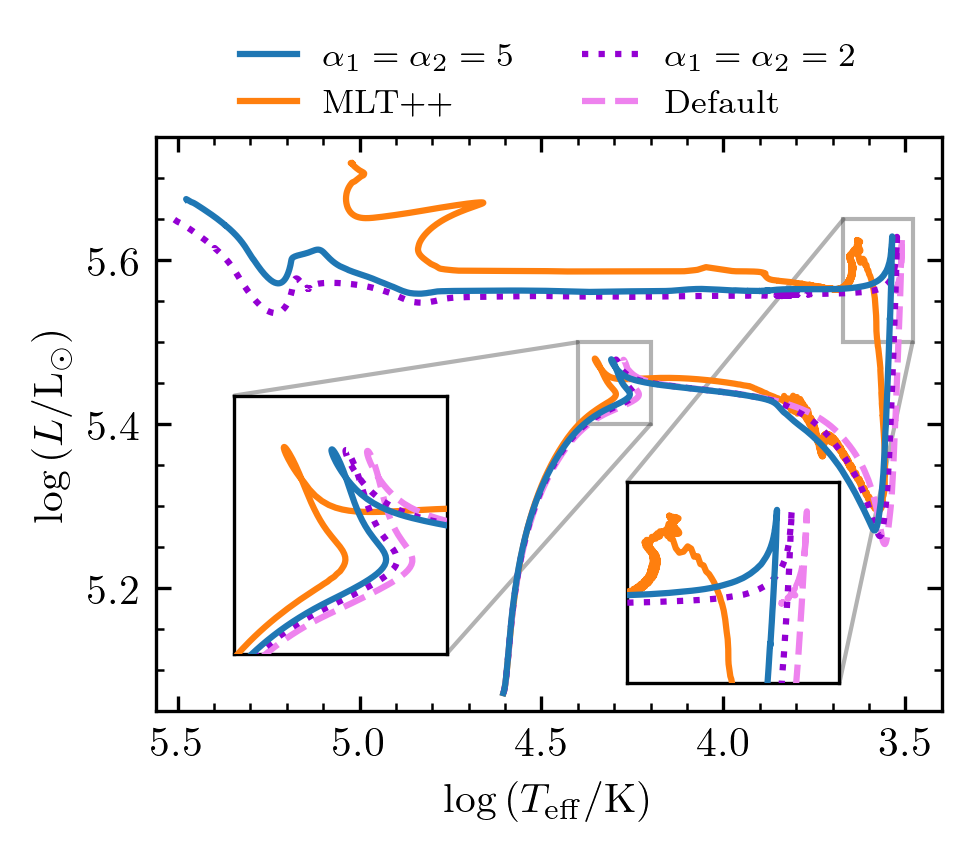

In [33]:
import matplotlib.pyplot as plt

plt.style.use("mesa.mplstyle")

histories = [md.mesa_data("single/3e1/LOGS/history.data"),
            md.mesa_data("single/3e1_mltpp/LOGS/history.data"),
             md.mesa_data("single/3e1_lesssuperad/LOGS/history.data"),
            md.mesa_data("single/3e1_normal/LOGS/history.data")]

colors = ["tab:blue", "tab:orange","darkviolet", "violet", "darkviolet", "skyblue", "tomato", "violet", "slateblue",
          "seagreen", "lightcoral"]
lss = ["-","-",":","--"]
labels = ["$\\alpha_1=\\alpha_2=5$",
          "MLT++","$\\alpha_1=\\alpha_2=2$","Default"]
zorders = [1000,100,500,200]

ax = plt.gca()

# inset axes....
axins = ax.inset_axes([0.1, 0.1, 0.27, 0.45])
# sub region of the original image
axins.set_xlim(4.4, 4.2)
axins.set_ylim(5.4, 5.5)
axins.set_xticklabels([])
axins.set_yticklabels([])
axins.set_xticks([])
axins.set_yticks([])

axins2 = ax.inset_axes([0.6, 0.05, 0.27, 0.35])
# sub region of the original image
axins2.set_xlim(3.67, 3.48)
axins2.set_ylim(5.5, 5.65)
axins2.set_xticklabels([])
axins2.set_yticklabels([])
axins2.set_xticks([])
axins2.set_yticks([])

ax.indicate_inset_zoom(axins, edgecolor="black", alpha=0.3)
ax.indicate_inset_zoom(axins2, edgecolor="black", alpha=0.3)

for k, premerger in enumerate(histories):
    for i in range(len(premerger.get("log_Teff"))):
        if premerger.get("center_h1")[i]<0.71:
            i_th = i
            break
    ax.plot(premerger.get("log_Teff")[i_th:-2], premerger.get("log_L")[i_th:-2],lw=1.5, 
            color=colors[k], ls=lss[k], label = labels[k], zorder=zorders[k])
    axins.plot(premerger.get("log_Teff")[i_th:-2], premerger.get("log_L")[i_th:-2],lw=1.5, 
            color=colors[k], ls=lss[k], label = labels[k], zorder=zorders[k])
    axins2.plot(premerger.get("log_Teff")[i_th:-2], premerger.get("log_L")[i_th:-2],lw=1.5, 
            color=colors[k], ls=lss[k], label = labels[k], zorder=zorders[k])
    

plt.gca().set_xlabel("$\\log\\left(T_\mathrm{eff}/\mathrm{K}\\right)$")
plt.gca().set_ylabel("$\\log\\left(L/\\mathrm{L}_\\odot\\right)$")
plt.gca().invert_xaxis()
plt.gca().set_xlim([5.56,3.4])
plt.gca().set_ylim([5.05,5.75])

plt.legend(loc=4,ncol=2,handlelength=1.7,bbox_to_anchor=(0.93, 0.98))

plt.savefig("HR_superad_comp.pdf")

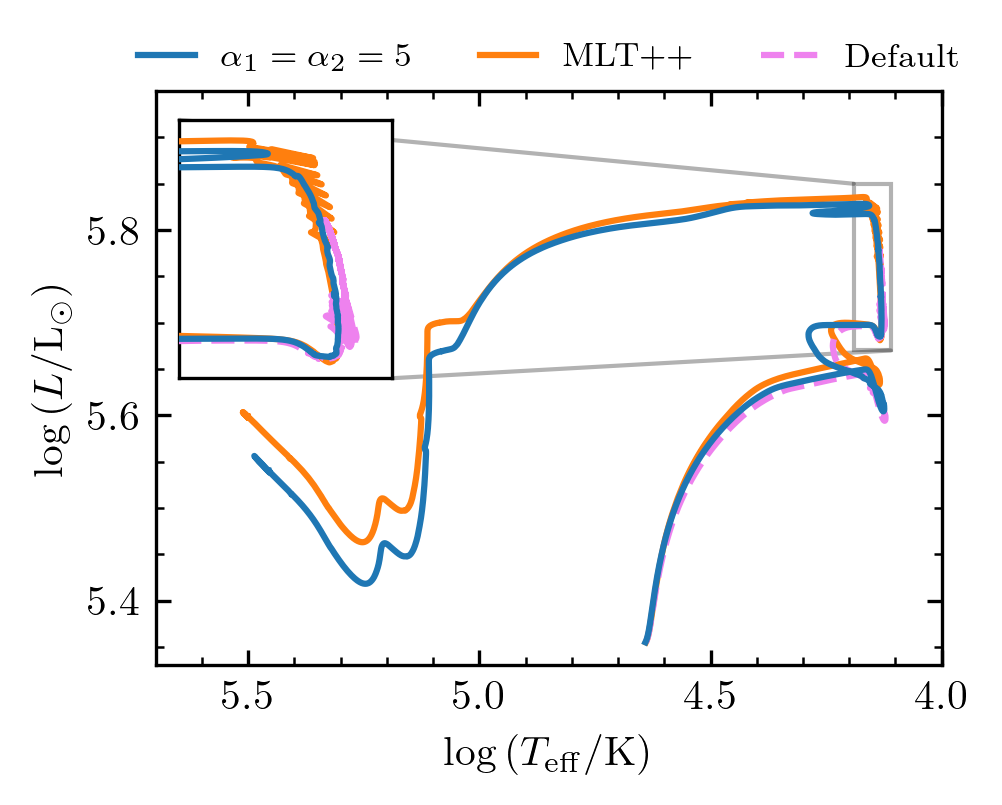

In [32]:
import matplotlib.pyplot as plt

plt.style.use("mesa.mplstyle")

histories = [md.mesa_data("binary/superad/LOGS1/history.data"),
            md.mesa_data("binary/mltpp/LOGS1/history.data"),
            md.mesa_data("binary/normal/LOGS1/history.data")]

colors = ["tab:blue", "tab:orange", "violet", "darkviolet", "skyblue", "tomato", "violet", "slateblue",
          "seagreen", "lightcoral","slategray"]
lss = ["-","-","--"]
labels = ["$\\alpha_1=\\alpha_2=5$","MLT++","Default"]
zorders = [1000,100,200]

ax = plt.gca()

# inset axes....
axins = ax.inset_axes([0.03, 0.5, 0.27, 0.45])
# sub region of the original image
axins.set_xlim(4.19, 4.11)
axins.set_ylim(5.67, 5.85)
axins.set_xticklabels([])
axins.set_yticklabels([])
axins.set_xticks([])
axins.set_yticks([])

ax.indicate_inset_zoom(axins, edgecolor="black", alpha=0.3)

for k, premerger in enumerate(histories):
    for i in range(len(premerger.get("log_Teff"))):
        if premerger.get("center_h1")[i]<0.71:
            i_th = i
            break
    ax.plot(premerger.get("log_Teff")[i_th:-2], premerger.get("log_L")[i_th:-2],lw=1.5, 
            color=colors[k], ls=lss[k], label = labels[k], zorder=zorders[k])
    axins.plot(premerger.get("log_Teff")[i_th:-2], premerger.get("log_L")[i_th:-2],lw=1.5, 
               color=colors[k], ls=lss[k], zorder=zorders[k])

plt.gca().set_xlabel("$\\log\\left(T_\mathrm{eff}/\mathrm{K}\\right)$")
plt.gca().set_ylabel("$\\log\\left(L/\\mathrm{L}_\\odot\\right)$")
plt.gca().invert_xaxis()
plt.gca().set_xlim([5.7,4])
plt.gca().set_ylim([5.33,5.95])

plt.legend(loc=4,ncol=3,handlelength=1.7,bbox_to_anchor=(1.06, 0.98))

plt.savefig("HR_superad_mass_transfer.pdf")

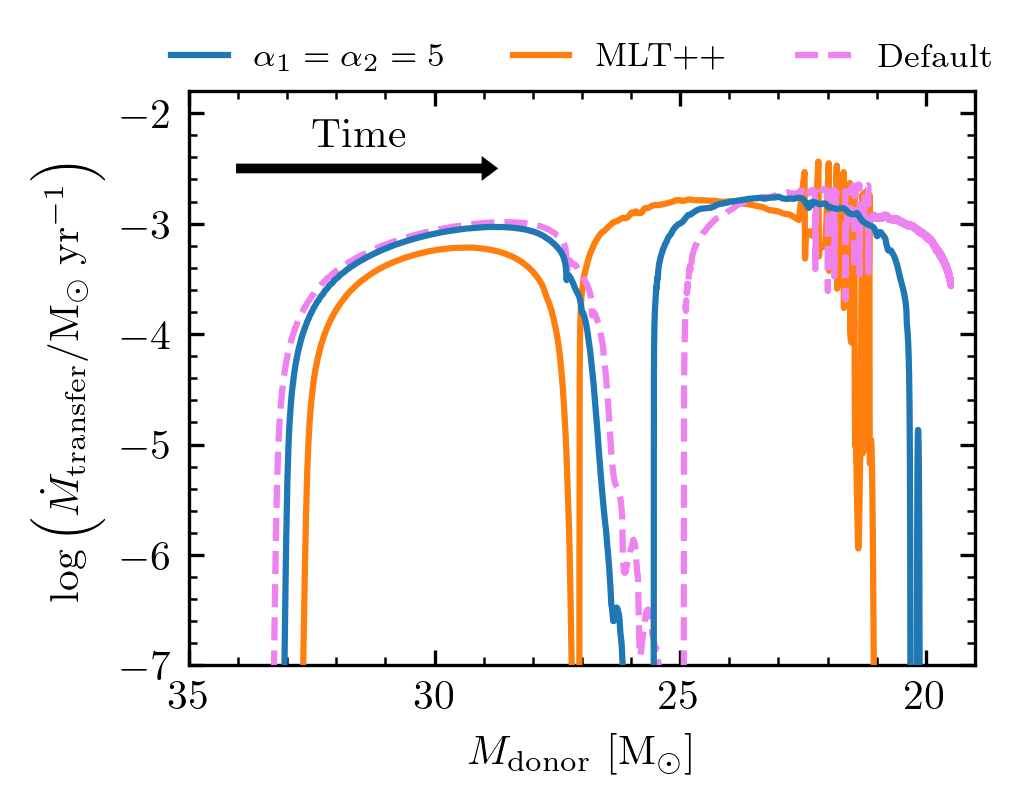

In [31]:
import matplotlib.pyplot as plt

plt.style.use("mesa.mplstyle")

histories = [md.mesa_data("binary/superad/LOGS1/history.data"),
            md.mesa_data("binary/mltpp/LOGS1/history.data"),
            md.mesa_data("binary/normal/LOGS1/history.data")]

colors = ["tab:blue", "tab:orange", "violet", "darkviolet", "skyblue", "tomato", "violet", "slateblue",
          "seagreen", "lightcoral","slategray"]
lss = ["-","-","--"]
labels = ["$\\alpha_1=\\alpha_2=5$","MLT++","Default"]
zorders = [1000,100,200]

ax = plt.gca()

for k, premerger in enumerate(histories):
    for i in range(len(premerger.get("log_Teff"))):
        if premerger.get("center_h1")[i]<0.71:
            i_th = i
            break
    for i in range(len(premerger.get("log_Teff"))):
        if premerger.get("lg_mtransfer_rate")[i] > -1: # clean errors in data output
            premerger.get("lg_mtransfer_rate")[i] = -99
    ax.plot(premerger.get("star_mass")[i_th:-2], premerger.get("lg_mtransfer_rate")[i_th:-2],lw=1.5, 
            color=colors[k], ls=lss[k], label = labels[k], zorder = zorders[k])

plt.gca().set_ylabel("$\\log\\left(\dot{M}_\mathrm{transfer}/\\mathrm{M}_\odot \; \\mathrm{yr}^{-1}\\right)$")
plt.gca().set_xlabel("$M_\\mathrm{donor}~[\\mathrm{M}_\\odot]$")
#plt.gca().invert_xaxis()
plt.gca().set_xlim([35,19])
plt.gca().set_ylim([-7,-1.8])

plt.arrow(34, -2.5, -5, 0,width=0.05, color="black")
plt.text(32.5,-2.3,"Time")

plt.legend(loc=4,ncol=3,handlelength=1.7,bbox_to_anchor=(1.06, 0.98))

plt.savefig("superad_mass_transfer.pdf")